In [1]:
import os, sys
import subprocess
import json
import uproot3
import awkward as ak
import numpy as np
from coffea import processor, util, hist
import matplotlib.pyplot as plt
import pickle

/opt/conda/lib/python3.8/site-packages/coffea/util.py:154: FutureWarning: In coffea version v0.8.0 (target date: 31 Dec 2022), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [2]:
ddbthr = 0.72
ddcthr = 0.15

In [3]:
!ls ../vh_combine/allyears_Oct12_masscut/2017

1mvc-signalregion.root	higgsCombineTest.FitDiagnostics.mH125.root
1mvl-signalregion.root	higgsCombineTest.Significance.mH125.root
combine_logger.out	make_workspace.sh
draw_datafit_MC.C	output
draw_datafit_fitD.C	plots
exp_shapes.sh		signalregion.root
exp_significance.sh	templates.pkl
fitDiagnostics.root


In [4]:
year='2017'

# Check if pickle exists     
picklename = '2017_allyearsRun_masscut_Oct192022_2017/ttbar_templates.pkl'
if not os.path.isfile(picklename):
    print("You need to create the pickle")

In [5]:
# Read the histogram from the pickle file
templates = pickle.load(open(picklename,'rb')).sum(*['genflavor1', 'genflavor2', 'msd2'], overflow='all').integrate('systematic','nominal').integrate('region','signal')
templates

<Hist (process,msd1,ddb1,ddc2) instance at 0x7ff411eb7bb0>

In [6]:
charmpass = templates.integrate('ddc2',int_range=slice(ddcthr,1)).integrate('ddb1',int_range=slice(ddbthr,1))
charmfail = templates.integrate('ddc2',int_range=slice(ddcthr,1)).integrate('ddb1',int_range=slice(0,ddbthr))

lightpass = templates.integrate('ddc2',int_range=slice(0,ddcthr)).integrate('ddb1',int_range=slice(ddbthr,1))
lightfail = templates.integrate('ddc2',int_range=slice(0,ddcthr)).integrate('ddb1',int_range=slice(0,ddbthr))

Text(0.5, 1.0, 'Light cat, DDB pass')

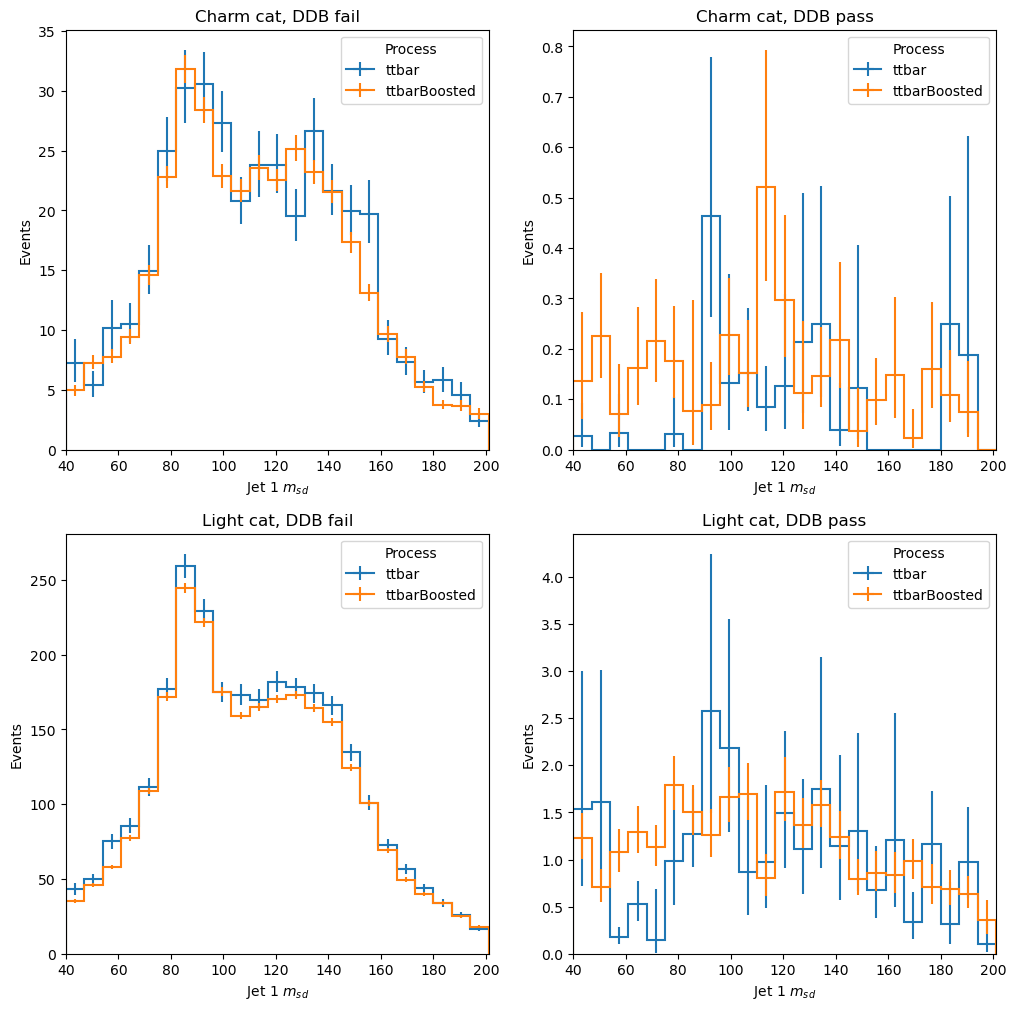

In [7]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(12,12))
hist.plot1d(charmfail,overlay='process',ax=ax1)
ax1.set_title('Charm cat, DDB fail')
hist.plot1d(charmpass,overlay='process',ax=ax2)
ax2.set_title('Charm cat, DDB pass')
hist.plot1d(lightfail,overlay='process',ax=ax3)
ax3.set_title('Light cat, DDB fail')
hist.plot1d(lightpass,overlay='process',ax=ax4)
ax4.set_title('Light cat, DDB pass')

In [38]:
templates.identifiers('process')

[<StringBin (Zjets) instance at 0x7fe61065f970>]

In [32]:
sig = templates.integrate('ddc2',slice(ddcthr,1)).sum(*['msd2'],overflow='all').integrate('process','Zjets')

In [33]:
sig

<Hist (msd1,ddb1) instance at 0x7fe610709430>

In [34]:
hpass = sig.integrate('ddb1',int_range=slice(ddbthr,1))

<AxesSubplot:xlabel='Jet 1 $m_{sd}$', ylabel='Events'>

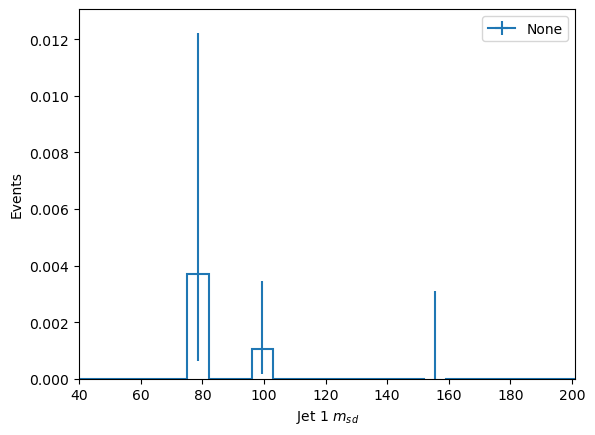

In [35]:
hist.plot1d(hpass)

<AxesSubplot:xlabel='Jet 2 $m_{sd}$', ylabel='Events'>

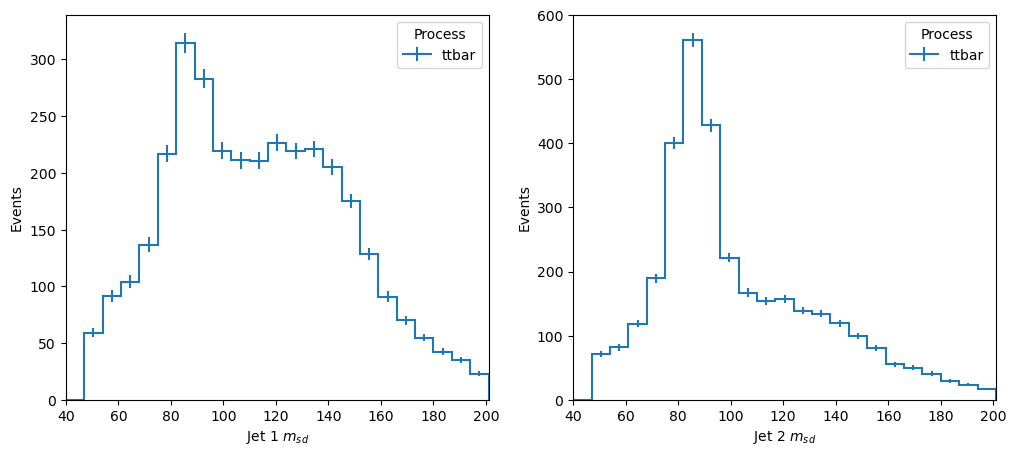

In [5]:
inclusive = templates.sum('ddb1','ddc2')

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
hist.plot1d(inclusive.sum('msd2'),overlay='process',ax=ax1)
hist.plot1d(inclusive.sum('msd1'),overlay='process',ax=ax2)

In [6]:
charmpass = templates.sum('msd2').integrate('ddc2',int_range=slice(ddcthr,1)).integrate('ddb1',int_range=slice(ddbthr,1))
charmfail = templates.sum('msd2').integrate('ddc2',int_range=slice(ddcthr,1)).integrate('ddb1',int_range=slice(0,ddbthr))

lightpass = templates.sum('msd2').integrate('ddc2',int_range=slice(0,ddcthr)).integrate('ddb1',int_range=slice(ddbthr,1))
lightfail = templates.sum('msd2').integrate('ddc2',int_range=slice(0,ddcthr)).integrate('ddb1',int_range=slice(0,ddbthr))

Text(0.5, 1.0, 'Light cat, DDB pass')

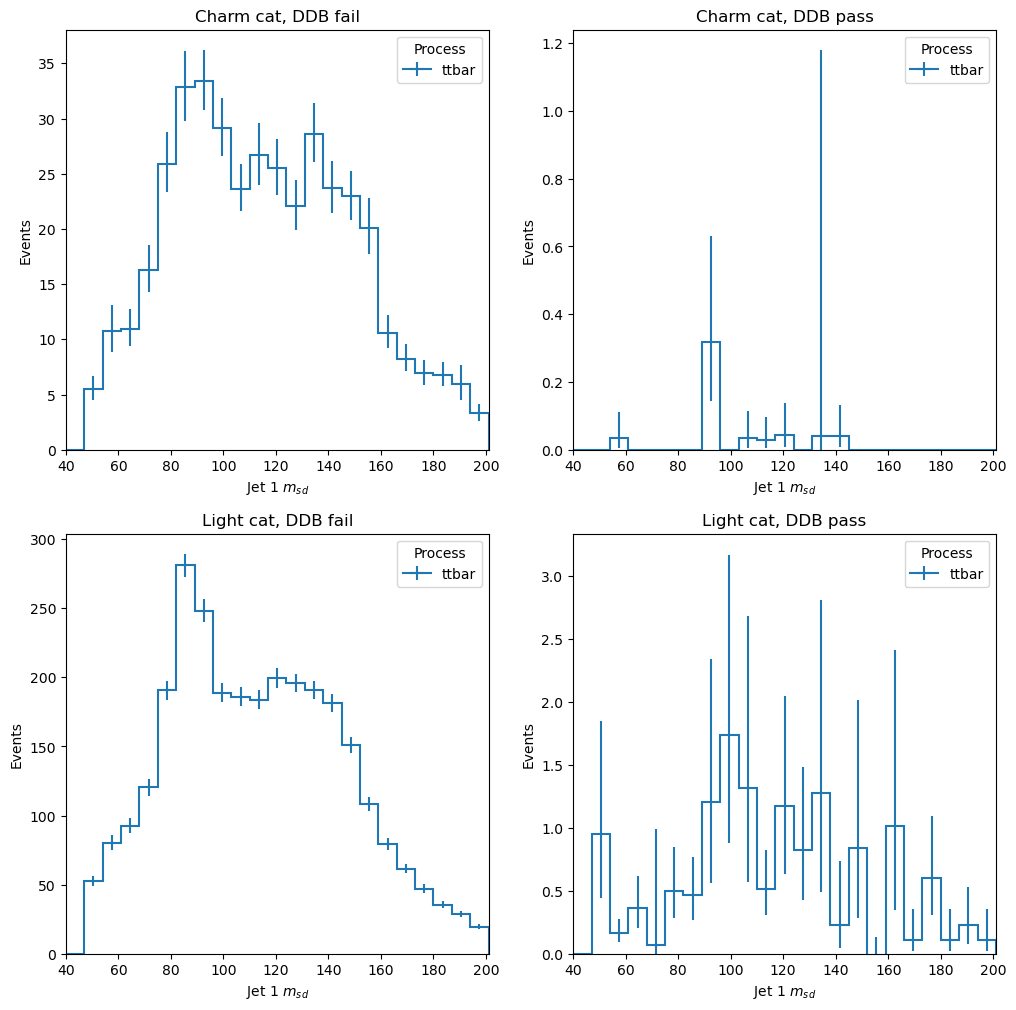

In [7]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(12,12))
hist.plot1d(charmfail,overlay='process',ax=ax1)
ax1.set_title('Charm cat, DDB fail')
hist.plot1d(charmpass,overlay='process',ax=ax2)
ax2.set_title('Charm cat, DDB pass')
hist.plot1d(lightfail,overlay='process',ax=ax3)
ax3.set_title('Light cat, DDB fail')
hist.plot1d(lightpass,overlay='process',ax=ax4)
ax4.set_title('Light cat, DDB pass')